In [1]:
# -*- coding: utf-8 -*-
import numpy as np
import cv2
import matplotlib.pyplot as plt
from collections import deque
import time
%matplotlib inline

BG_SECONDS = 3
MOTION_SECONDS = 5
FPS_APPROX = 10
N_BG_FRAMES = BG_SECONDS * FPS_APPROX
N_MOT_FRAMES = MOTION_SECONDS * FPS_APPROX

THRESHOLD = 15
MORPH_SIZE = 5
CAM_ID = 0   


ЗАПИСЬ ФОНА
  кадр 0
  кадр 10
  кадр 20
Захвачено кадров фона: 30


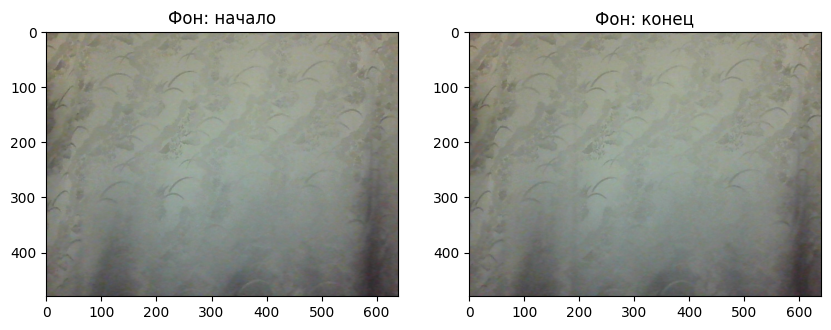

In [2]:
print("ЗАПИСЬ ФОНА")
cap = cv2.VideoCapture(CAM_ID)
if not cap.isOpened():
    raise RuntimeError("Камера не найдена")

bg_frames = []
for i in range(N_BG_FRAMES):
    ret, frame = cap.read()
    if ret:
        img = frame[:, :, ::-1].copy()   # BGR -> RGB
        bg_frames.append(img)
    if i % FPS_APPROX == 0:
        print(f"  кадр {i}")
    cv2.waitKey(100)
cap.release()
print(f"Захвачено кадров фона: {len(bg_frames)}")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(bg_frames[0]);  plt.title('Фон: начало')
plt.subplot(1,2,2); plt.imshow(bg_frames[-1]); plt.title('Фон: конец')
plt.show()


ЗАПИСЬ ДВИЖЕНИЯ
  кадр 0
  кадр 10
  кадр 20
  кадр 30
  кадр 40
Захвачено кадров движения: 50


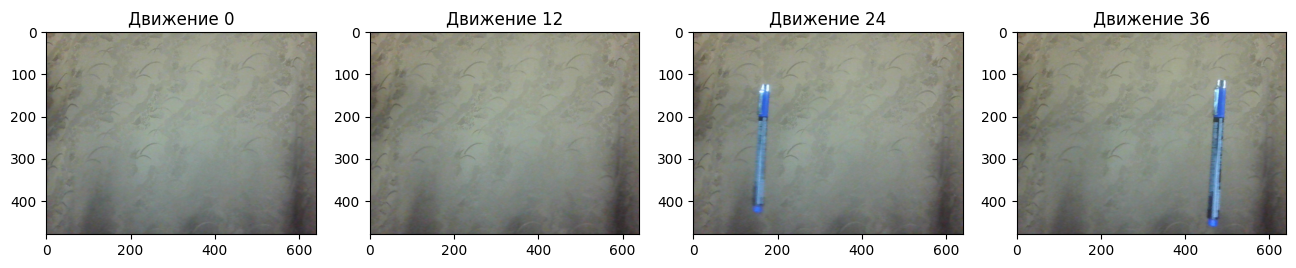

In [3]:
print("\nЗАПИСЬ ДВИЖЕНИЯ")
cap = cv2.VideoCapture(CAM_ID)
motion_frames = []
for i in range(N_MOT_FRAMES):
    ret, frame = cap.read()
    if ret:
        img = frame[:, :, ::-1].copy()
        motion_frames.append(img)
    if i % FPS_APPROX == 0:
        print(f"  кадр {i}")
    cv2.waitKey(100)
cap.release()
print(f"Захвачено кадров движения: {len(motion_frames)}")

step = max(1, len(motion_frames)//4)
indices = list(range(0, len(motion_frames), step))[:4]
plt.figure(figsize=(16,4))
for i, idx in enumerate(indices):
    plt.subplot(1,4,i+1); plt.imshow(motion_frames[idx]); plt.title(f'Движение {idx}')
plt.show()

In [4]:
def construct_background(sequence):
    accum = np.zeros_like(sequence[0], dtype=np.float64)
    for f in sequence:
        accum += f.astype(np.float64)
    accum /= len(sequence)
    return accum

def difference_mask(frame, bg, thr):
    d = np.abs(frame.astype(np.float64) - bg.astype(np.float64))
    gray = (d[:,:,0] + d[:,:,1] + d[:,:,2]) / 3.0
    mask = np.zeros_like(gray, dtype=np.uint8)
    mask[gray > thr] = 255
    return gray, mask

def erode_manual(mask, ksize):
    h, w = mask.shape
    pad = ksize // 2
    bin_mask = mask > 0
    padded = np.pad(bin_mask, pad, mode='constant', constant_values=True)
    res = np.zeros_like(mask, dtype=np.uint8)
    for y in range(h):
        for x in range(w):
            window = padded[y:y+ksize, x:x+ksize]
            res[y, x] = 255 if np.all(window) else 0
    return res

def dilate_manual(mask, ksize):
    h, w = mask.shape
    pad = ksize // 2
    bin_mask = mask > 0
    padded = np.pad(bin_mask, pad, mode='constant', constant_values=False)
    res = np.zeros_like(mask, dtype=np.uint8)
    for y in range(h):
        for x in range(w):
            window = padded[y:y+ksize, x:x+ksize]
            res[y, x] = 255 if np.any(window) else 0
    return res

def clean_mask(mask, ksize):
    return dilate_manual(erode_manual(mask, ksize), ksize)

def extract_blob_info(mask):
    h, w = mask.shape
    seen = np.zeros((h, w), dtype=bool)
    best_set = None
    best_cx = best_cy = None
    best_bbox = None
    best_border = None

    for y in range(h):
        for x in range(w):
            if mask[y, x] == 255 and not seen[y][x]:
                q = deque()
                q.append((x, y))
                seen[y][x] = True
                pixels = set()
                pixels.add((x, y))
                while q:
                    cx, cy = q.popleft()
                    for nx, ny in [(cx-1,cy),(cx+1,cy),(cx,cy-1),(cx,cy+1)]:
                        if 0 <= nx < w and 0 <= ny < h and mask[ny, nx] == 255 and not seen[ny][nx]:
                            seen[ny][nx] = True
                            q.append((nx, ny))
                            pixels.add((nx, ny))
                if len(pixels) > len(best_set or []):
                    best_set = pixels
                    xs = [p[0] for p in pixels]
                    ys = [p[1] for p in pixels]
                    best_cx = int(np.mean(xs))
                    best_cy = int(np.mean(ys))
                    best_bbox = (min(xs), min(ys), max(xs), max(ys))
                    # граничные пиксели
                    best_border = set()
                    for (px, py) in pixels:
                        is_border = False
                        for nx, ny in [(px-1,py),(px+1,py),(px,py-1),(px,py+1)]:
                            if (nx, ny) not in pixels:
                                is_border = True
                                break
                        if is_border:
                            best_border.add((px, py))
    return best_set, (best_cx, best_cy) if best_set else None, best_bbox, best_border

def draw_line(pic, p1, p2, color):
    x1, y1 = p1
    x2, y2 = p2
    dx = abs(x2 - x1)
    dy = -abs(y2 - y1)
    sx = 1 if x1 < x2 else -1
    sy = 1 if y1 < y2 else -1
    err = dx + dy
    while True:
        if 0 <= x1 < pic.shape[1] and 0 <= y1 < pic.shape[0]:
            pic[y1, x1] = color
        if x1 == x2 and y1 == y2:
            break
        e2 = 2 * err
        if e2 >= dy:
            err += dy
            x1 += sx
        if e2 <= dx:
            err += dx
            y1 += sy

def draw_rect(pic, x0, y0, x1, y1, color):
    for x in range(x0, x1+1):
        pic[y0, x] = color
        pic[y1, x] = color
    for y in range(y0, y1+1):
        pic[y, x0] = color
        pic[y, x1] = color

def draw_spot(pic, centre, r, color):
    cx, cy = centre
    for dx in range(-r, r+1):
        for dy in range(-r, r+1):
            nx, ny = cx+dx, cy+dy
            if 0 <= nx < pic.shape[1] and 0 <= ny < pic.shape[0]:
                pic[ny, nx] = color

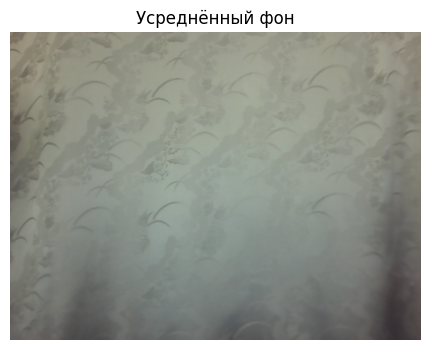

In [5]:
background = construct_background(bg_frames)

plt.figure(figsize=(6,4))
plt.imshow(background.astype(np.uint8))
plt.title('Усреднённый фон')
plt.axis('off')
plt.show()

In [6]:
test_frame = motion_frames[len(motion_frames)//2]
diff_gray, mask_raw = difference_mask(test_frame, background, THRESHOLD)
mask_clean = clean_mask(mask_raw, MORPH_SIZE)

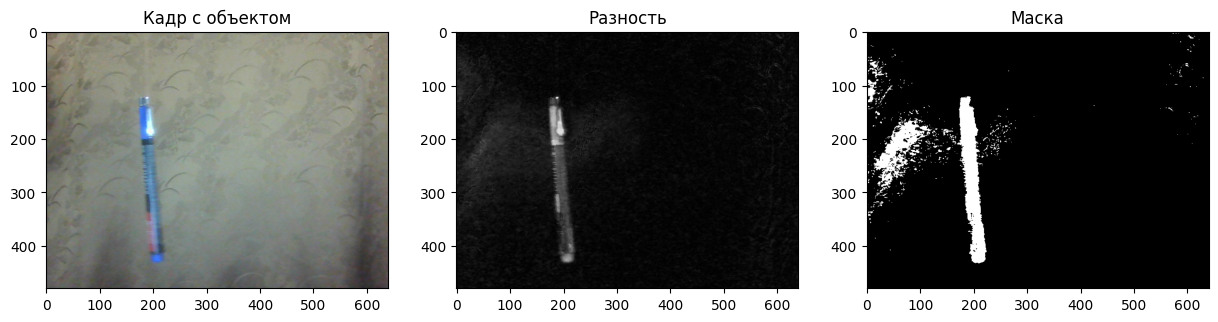

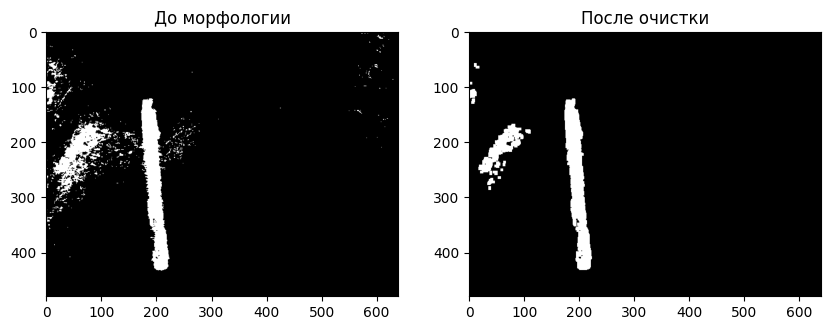

In [7]:
plt.figure(figsize=(15,4))
plt.subplot(1,3,1); plt.imshow(test_frame); plt.title('Кадр с объектом')
plt.subplot(1,3,2); plt.imshow(diff_gray, cmap='gray'); plt.title('Разность')
plt.subplot(1,3,3); plt.imshow(mask_raw, cmap='gray'); plt.title('Маска')
plt.show()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(mask_raw, cmap='gray'); plt.title('До морфологии')
plt.subplot(1,2,2); plt.imshow(mask_clean, cmap='gray'); plt.title('После очистки')
plt.show()

Центроид: (195, 275)
Bounding box: (173, 122, 222, 432)


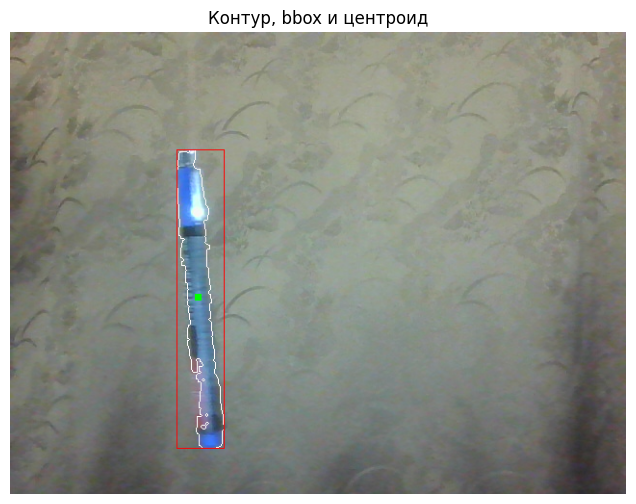

In [8]:
_, centroid, bbox, border = extract_blob_info(mask_clean)
print(f"Центроид: {centroid}")
print(f"Bounding box: {bbox}")

if centroid and bbox and border:
    canvas = test_frame.copy()
    for (bx, by) in border:
        if 0 <= bx < canvas.shape[1] and 0 <= by < canvas.shape[0]:
            canvas[by, bx] = [255, 255, 255]   # белый контур
    draw_rect(canvas, bbox[0], bbox[1], bbox[2], bbox[3], [255, 0, 0])   # синяя рамка
    draw_spot(canvas, centroid, 3, [0, 255, 0])   # зелёный центроид

    plt.figure(figsize=(8,6))
    plt.imshow(canvas)
    plt.title('Контур, bbox и центроид')
    plt.axis('off')
    plt.show()

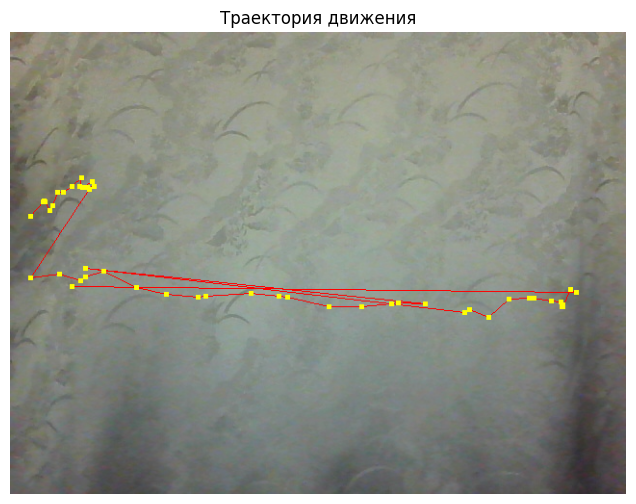

In [9]:
positions = []
for frame in motion_frames:
    _, msk = difference_mask(frame, background, THRESHOLD)
    msk_cl = clean_mask(msk, MORPH_SIZE)
    _, ct, _, _ = extract_blob_info(msk_cl)
    if ct:
        positions.append(ct)

if positions:
    trail_img = motion_frames[0].copy()
    for i in range(1, len(positions)):
        draw_line(trail_img, positions[i-1], positions[i], [255, 0, 0])
    for pt in positions:
        draw_spot(trail_img, pt, 2, [255, 255, 0])

    plt.figure(figsize=(8,6))
    plt.imshow(trail_img)
    plt.title('Траектория движения')
    plt.axis('off')
    plt.show()

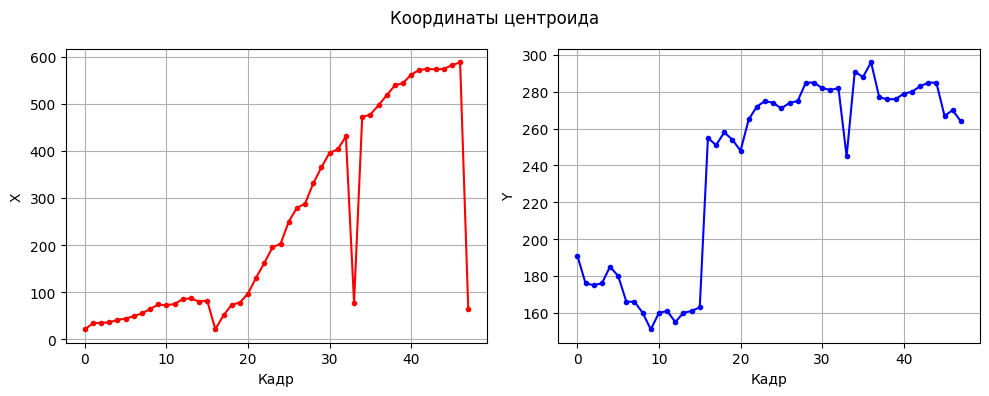

In [10]:
    xs = [p[0] for p in positions]
    ys = [p[1] for p in positions]
    idxs = list(range(len(positions)))
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(idxs, xs, 'r.-')
    plt.xlabel('Кадр')
    plt.ylabel('X')
    plt.grid(True)
    plt.subplot(1,2,2)
    plt.plot(idxs, ys, 'b.-')
    plt.xlabel('Кадр')
    plt.ylabel('Y')
    plt.grid(True)
    plt.suptitle('Координаты центроида')
    plt.tight_layout()
    plt.show()